In [17]:
import sys, subprocess
print("Kernel Python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pip", "pandas", "pingouin", "seaborn", "ipython", "openpyxl", "numpy", "matplotlib", "japanize-matplotlib", "factor-analyzer", "statsmodels", "scikit_posthocs"])
# ノートブック内から導入


Kernel Python: c:\Users\yuki4\AppData\Local\Programs\Python\Python310\python.exe


0

In [18]:
import pandas as pd
import seaborn
from IPython.display import display
import openpyxl

df_Conflict = pd.read_excel('scene1_2nd.xlsx', sheet_name='葛藤', usecols='A:D')
df_Conflict2 = pd.read_excel('scene2_2nd.xlsx', sheet_name='葛藤', usecols='A:D')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from factor_analyzer import FactorAnalyzer

# 変数の標準化
df_Conflict_std = df_Conflict.apply(lambda x: (x-x.mean())/x.std(), axis=0)
df_Conflict_std2 = df_Conflict2.apply(lambda x: (x-x.mean())/x.std(), axis=0)



In [19]:
# 固有値を求める
ei = np.linalg.eigvals(df_Conflict.corr())
ei2 = np.linalg.eigvals(df_Conflict2.corr())
print("固有値（scene1.xlsx）:", ei)
print("固有値（scene2.xlsx）:", ei2)

固有値（scene1.xlsx）: [3.29287016 0.30108736 0.22291146 0.18313102]
固有値（scene2.xlsx）: [2.99306797 0.50072754 0.28492291 0.22128158]


In [20]:
# 因子分析（因子数 = 1）
from factor_analyzer import FactorAnalyzer
import pandas as pd
import matplotlib.pyplot as plt

# --------- 前処理済みデータフレーム df_Conflict_std を想定 ---------

# 因子分析の実行
fa = FactorAnalyzer(n_factors=1, rotation=None)   # 1因子なので回転は省略
fa.fit(df_Conflict_std)

# 因子負荷量・共通性
loadings_df = pd.DataFrame(
    fa.loadings_,
    columns=["第1因子"],
    index=df_Conflict_std.columns
)
loadings_df["共通性"] = fa.get_communalities()
display(loadings_df)

# 因子負荷量の二乗和・寄与率・累積寄与率
var = fa.get_factor_variance()           # (3, 1) の配列
df_var = pd.DataFrame(
    {
        "因子負荷量の二乗和": var[0],
        "寄与率": var[1],
        "累積寄与率": var[2]
    },
    index=["第1因子"]
)
display(df_var.T)



c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,第1因子,共通性
このロボットは、目の前のことをやりたいけれど、怖くてためらっているように見えた。,-0.878126,0.771105
このロボットは、自分の行動に迷いや揺れがあるように見えた。,-0.897732,0.805922
このロボットは、やりたいという気持ちとやりたくない気持ちが混在しているように見えた。,-0.845271,0.714484
このロボットは、自分の行動を決めかねているように見えた。,-0.875814,0.767049


,第1因子
因子負荷量の二乗和,3.05856
寄与率,0.76464
累積寄与率,0.76464


In [21]:
# 因子分析（因子数 = 1）
from factor_analyzer import FactorAnalyzer
import pandas as pd
import matplotlib.pyplot as plt

# --------- 前処理済みデータフレーム df_Conflict_std を想定 ---------

# 因子分析の実行
fa = FactorAnalyzer(n_factors=1, rotation=None)   # 1因子なので回転は省略
fa.fit(df_Conflict_std2)

# 因子負荷量・共通性
loadings_df2 = pd.DataFrame(
    fa.loadings_,
    columns=["第1因子"],
    index=df_Conflict_std2.columns
)
loadings_df2["共通性"] = fa.get_communalities()
display(loadings_df2)

# 因子負荷量の二乗和・寄与率・累積寄与率
var2 = fa.get_factor_variance()           # (3, 1) の配列
df2_var = pd.DataFrame(
    {
        "因子負荷量の二乗和": var2[0],
        "寄与率": var2[1],
        "累積寄与率": var2[2]
    },
    index=["第1因子"]
)
display(df2_var.T)



c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,第1因子,共通性
このロボットは、目の前のことをやりたいけれど、怖くてためらっているように見えた。,-0.826828,0.683645
このロボットは、自分の行動に迷いや揺れがあるように見えた。,-0.844653,0.713439
このロボットは、やりたいという気持ちとやりたくない気持ちが混在しているように見えた。,-0.753705,0.568071
このロボットは、自分の行動を決めかねているように見えた。,-0.835043,0.697297


,第1因子
因子負荷量の二乗和,2.662452
寄与率,0.665613
累積寄与率,0.665613


In [22]:
score_Conflict_5 = pd.read_excel('scene1_2nd.xlsx', sheet_name='葛藤', usecols='E').to_numpy()
score_Conflict2_5 = pd.read_excel('scene2_2nd.xlsx', sheet_name='葛藤', usecols='E').to_numpy()

score_Conflict_14 = fa.transform(df_Conflict_std)
score_Conflict2_14 = fa.transform(df_Conflict_std2)

from scipy.stats import pearsonr


# 因子得点の符号を逆にする
score_Conflict_14_inverted = -score_Conflict_14
score_Conflict2_14_inverted = -score_Conflict2_14

# 再度相関係数を計算
from scipy.stats import pearsonr
r, p = pearsonr(score_Conflict_5.flatten(), score_Conflict_14_inverted.flatten())
print(f"符号反転後の相関係数: r = {r:.3f}, p値 = {p:.4f}")
r, p = pearsonr(score_Conflict2_5.flatten(), score_Conflict2_14_inverted.flatten())
print(f"符号反転後の相関係数: r = {r:.3f}, p値 = {p:.4f}")


c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


符号反転後の相関係数: r = 0.887, p値 = 0.0000
符号反転後の相関係数: r = 0.827, p値 = 0.0000


In [23]:
def cronbach_alpha(df):
    item_vars = df.var(axis=0, ddof=1)
    total_var = df.sum(axis=1).var(ddof=1)
    n_items = df.shape[1]
    return (n_items / (n_items - 1)) * (1 - item_vars.sum() / total_var)

# 対象のデータフレームを辞書にまとめる
scales = {
    "葛藤1": df_Conflict,
    "葛藤2": df_Conflict2,
}

print("クロンバックのα係数")
for name, df in scales.items():
    alpha = cronbach_alpha(df)
    print(f"{name} = {alpha:.3f}")

クロンバックのα係数
葛藤1 = 0.928
葛藤2 = 0.887


In [24]:
import pandas as pd
import numpy as np
import pingouin as pg

# ── 読み込み（A:Dのみ） ───────────────────────────────
df_scene1 = pd.read_excel("scene1_2nd.xlsx", sheet_name="葛藤", usecols="A:D")
df_scene2 = pd.read_excel("scene2_2nd.xlsx", sheet_name="葛藤", usecols="A:D")

# 列名を整理
df_scene1.columns = [f"Q{i}" for i in range(1, 5)]
df_scene2.columns = [f"Q{i}" for i in range(1, 5)]

# 各シーンの被験者数
n_subj_scene1 = 131
n_subj_scene2 = 115

# 条件ラベル（行ブロックの順序がこの通りである前提）
order_labels = [
    ("NoConflict", "Sequential"),
    ("NoConflict", "Simultaneous"),
    ("Conflict",   "Sequential"),
    ("Conflict",   "Simultaneous"),
]

# ── 整形関数（シーンごとに） ─────────────────────────
def reshape_scene(df, n_subj, scene_label):
    assert len(df) == 4 * n_subj, f"{scene_label}: 行数が 4×被験者数 と一致しません"

    # 要因ラベルを行に割り当て
    conflict = np.repeat([c for c, p in order_labels], n_subj)
    presentation = np.repeat([p for c, p in order_labels], n_subj)
    subject = np.tile(np.arange(1, n_subj + 1), 4)

    df = df.copy()
    df["Conflict"] = conflict
    df["Presentation"] = presentation
    df["subject"] = subject
    df["scene"] = scene_label

    # wide → long
    long = df.melt(
        id_vars=["subject", "scene", "Conflict", "Presentation"],
        value_vars=["Q1", "Q2", "Q3", "Q4"],
        var_name="item",
        value_name="score"
    )

    # 項目平均で1スコアに
    long_mean = (
        long.groupby(["subject", "scene", "Conflict", "Presentation"], as_index=False)["score"]
        .mean()
        .rename(columns={"score": "score_mean"})
    )

    return long_mean

df1 = reshape_scene(df_scene1, n_subj_scene1, "Scene1")
df2 = reshape_scene(df_scene2, n_subj_scene2, "Scene2")



In [25]:
# 平均値を確認
print("=== Scene1 の平均値 ===")
display(df1.groupby(['Conflict', 'Presentation'])['score_mean'].agg(['mean', 'std', 'count']).round(3))
print("\n=== Scene2 の平均値 ===")
display(df2.groupby(['Conflict', 'Presentation'])['score_mean'].agg(['mean', 'std', 'count']).round(3))

=== Scene1 の平均値 ===


mean    std  count
Conflict   Presentation                     
Conflict   Sequential    4.964  1.201    131
           Simultaneous  5.344  1.079    131
NoConflict Sequential    3.615  1.561    131
           Simultaneous  4.303  1.403    131


=== Scene2 の平均値 ===


mean    std  count
Conflict   Presentation                     
Conflict   Sequential    4.667  1.233    115
           Simultaneous  5.104  1.141    115
NoConflict Sequential    3.535  1.392    115
           Simultaneous  4.085  1.293    115

In [26]:
def run_anova(df_mean, scene_label):
    sub = df_mean[df_mean["scene"] == scene_label].copy()

    # 2×2 within-within ANOVA
    aov = pg.rm_anova(
        dv="score_mean",
        within=["Conflict", "Presentation"],
        subject="subject",
        data=sub,
        detailed=True,
        effsize="np2"
    )

    # 単純主効果
    # PresentationごとのConflict
    simple_A = []
    for p in sub["Presentation"].unique():
        s = sub[sub["Presentation"] == p]
        res = pg.pairwise_ttests(
            dv="score_mean", within="Conflict", subject="subject",
            data=s, padjust="holm", effsize="hedges"
        )
        res["Presentation_level"] = p
        simple_A.append(res)
    simple_A = pd.concat(simple_A, ignore_index=True)

    # ConflictごとのPresentation
    simple_B = []
    for c in sub["Conflict"].unique():
        s = sub[sub["Conflict"] == c]
        res = pg.pairwise_ttests(
            dv="score_mean", within="Presentation", subject="subject",
            data=s, padjust="holm", effsize="hedges"
        )
        res["Conflict_level"] = c
        simple_B.append(res)
    simple_B = pd.concat(simple_B, ignore_index=True)

    return aov, simple_A, simple_B

aov1, simpleA1, simpleB1 = run_anova(df1, "Scene1")
aov2, simpleA2, simpleB2 = run_anova(df2, "Scene2")

print("Scene1 ANOVA")
display(aov1)
print("\nScene1 単純主効果: PresentationごとのConflict")
display(simpleA1[["Presentation_level","A","B","T","dof","p-unc","hedges"]])
print("\nScene1 単純主効果: ConflictごとのPresentation")
display(simpleB1[["Conflict_level","A","B","T","dof","p-unc","hedges"]])
print("\n\nScene2 ANOVA")
display(aov2)
print("\nScene2 単純主効果: PresentationごとのConflict")
display(simpleA2[["Presentation_level","A","B","T","dof","p-unc","hedges"]])
print("\nScene2 単純主効果: ConflictごとのPresentation")
display(simpleB2[["Conflict_level","A","B","T","dof","p-unc","hedges"]])


Scene1 ANOVA


c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\pingouin\pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)
c:\Users\yuki4\AppData\Local\Programs\Python\Python310\lib\site-packages\pingouin\pairwise.py:28: UserWarning: pairwise_ttests is deprecated, use p

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,np2,eps
0,Conflict,186.963740,1,130,186.963740,79.557734,3.722203e-15,3.722203e-15,0.379646,1.0
1,Presentation,37.404580,1,130,37.404580,46.447932,3.172688e-10,3.172688e-10,0.263239,1.0
2,Conflict * Presentation,3.130248,1,130,3.130248,4.923501,2.822843e-02,2.822843e-02,0.036491,1.0



Scene1 単純主効果: PresentationごとのConflict


,Presentation_level,A,B,T,dof,p-unc,hedges
0,Sequential,Conflict,NoConflict,8.678921,130.0,1.426142e-14,0.965877
1,Simultaneous,Conflict,NoConflict,7.107036,130.0,7.020059e-11,0.828850


...

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,np2,eps
0,Conflict,133.165761,1,114,133.165761,80.035100,7.835265e-15,7.835265e-15,0.412477,1.0
1,Presentation,28.004891,1,114,28.004891,33.774258,5.723296e-08,5.723296e-08,0.228553,1.0
2,Conflict * Presentation,0.367391,1,114,0.367391,0.564731,4.539090e-01,4.539090e-01,0.004929,1.0



Scene2 単純主効果: PresentationごとのConflict


,Presentation_level,A,B,T,dof,p-unc,hedges
0,Sequential,Conflict,NoConflict,7.725352,114.0,4.734732e-12,0.858803
1,Simultaneous,Conflict,NoConflict,7.444625,114.0,1.995347e-11,0.833413



Scene2 単純主効果: ConflictごとのPresentation


,Conflict_level,A,B,T,dof,p-unc,hedges
0,Conflict,Sequential,Simultaneous,-4.735839,114.0,0.000006,-0.366710
1,NoConflict,Sequential,Simultaneous,-4.191082,114.0,0.000055,-0.408125



=== Scene1 残差の正規性チェック ===
Shapiro-Wilk: W=0.992, p=0.0057
Anderson-Darling: stat=1.125, crit=[0.572 0.651 0.781 0.911 1.084]
Jarque-Bera: JB=7.878, p=0.0195
Skewness=-0.292, Kurtosis=-0.144


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' n

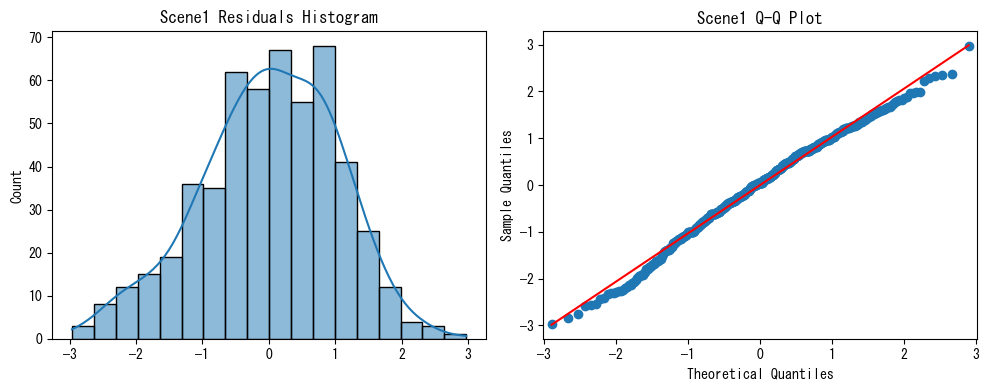

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' n


=== Scene2 残差の正規性チェック ===
Shapiro-Wilk: W=0.987, p=0.000549
Anderson-Darling: stat=1.613, crit=[0.571 0.65  0.78  0.91  1.083]
Jarque-Bera: JB=15.760, p=0.000378
Skewness=-0.431, Kurtosis=0.284


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' n

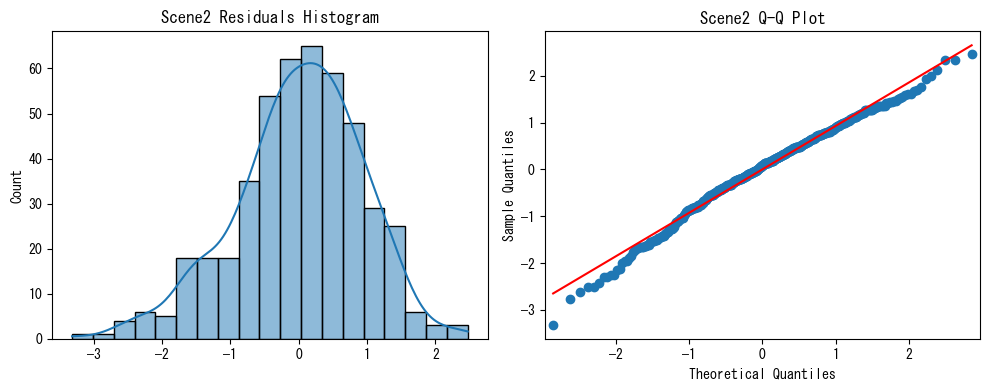

In [27]:
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

def check_residuals(df_scene, scene_label):
    print(f"\n=== {scene_label} 残差の正規性チェック ===")
    
    # 2×2（within–within）の混合効果モデル
    model = mixedlm("score_mean ~ Conflict * Presentation",
                    data=df_scene,
                    groups=df_scene["subject"])
    result = model.fit()
    
    # 残差
    residuals = result.resid
    
    # --- 正規性検定 ---
    # Shapiro–Wilk
    W, p_shapiro = stats.shapiro(residuals)
    print(f"Shapiro-Wilk: W={W:.3f}, p={p_shapiro:.3g}")
    
    # Anderson–Darling
    ad_result = stats.anderson(residuals, dist='norm')
    print(f"Anderson-Darling: stat={ad_result.statistic:.3f}, crit={ad_result.critical_values}")
    
    # Jarque–Bera
    jb_stat, jb_p = stats.jarque_bera(residuals)
    print(f"Jarque-Bera: JB={jb_stat:.3f}, p={jb_p:.3g}")
    
    # 歪度・尖度
    skewness = stats.skew(residuals)
    kurtosis = stats.kurtosis(residuals)  # Fisher補正あり（正規分布なら0）
    print(f"Skewness={skewness:.3f}, Kurtosis={kurtosis:.3f}")
    
    # --- 可視化（ヒストグラム＋QQプロット） ---
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    
    # ヒストグラム
    sns.histplot(residuals, kde=True, ax=axes[0])
    axes[0].set_title(f"{scene_label} Residuals Histogram")
    
    # QQプロット
    sm.qqplot(residuals, line='s', ax=axes[1])
    axes[1].set_title(f"{scene_label} Q-Q Plot")
    
    plt.tight_layout()
    plt.show()
    
    return residuals

resid1 = check_residuals(df1, "Scene1")
resid2 = check_residuals(df2, "Scene2")


In [28]:
# 平均値を確認
print("=== Scene1 の平均値 ===")
print(df1.groupby(['Conflict', 'Presentation'])['score_mean'].agg(['mean', 'std', 'count']).round(3))
print("\n=== Scene2 の平均値 ===")
print(df2.groupby(['Conflict', 'Presentation'])['score_mean'].agg(['mean', 'std', 'count']).round(3))

=== Scene1 の平均値 ===
                          mean    std  count
Conflict   Presentation                     
Conflict   Sequential    4.964  1.201    131
           Simultaneous  5.344  1.079    131
NoConflict Sequential    3.615  1.561    131
           Simultaneous  4.303  1.403    131

=== Scene2 の平均値 ===
                          mean    std  count
Conflict   Presentation                     
Conflict   Sequential    4.667  1.233    115
           Simultaneous  5.104  1.141    115
NoConflict Sequential    3.535  1.392    115
           Simultaneous  4.085  1.293    115


findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' n

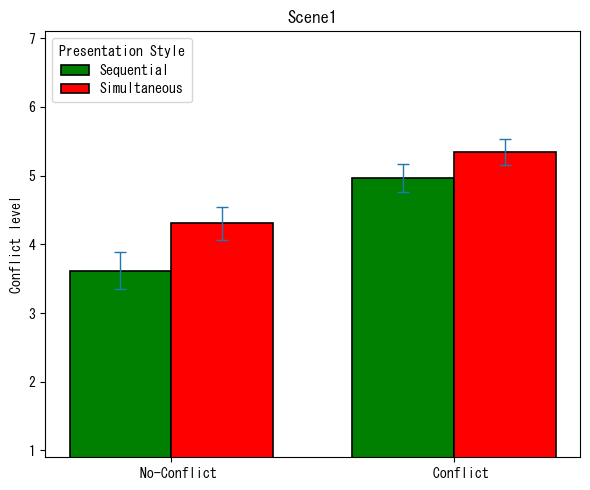

findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' not found.
findfont: Font family 'Noto Sans CJK JP' not found.
findfont: Font family 'Hiragino Sans' n

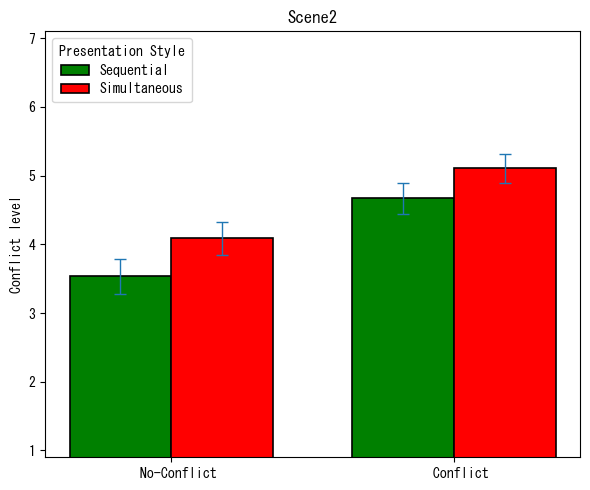

In [42]:
# 2×2（within–within）：要因＝【葛藤：なし/あり】【表示：連続/simultaneous】の棒グラフ（平均＋95%CI）
# 前提：df1 / df2 は各シーンの long_mean（列: subject, Conflict, Presentation, score_mean）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 日本語フォント（必要に応じて調整）
plt.rcParams["font.family"] = ["MS Gothic", "Yu Gothic", "Noto Sans CJK JP", "Hiragino Sans"]

def mean_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)
    m = x.mean()
    if n <= 1:
        return m, np.nan
    se = x.std(ddof=1) / np.sqrt(n)
    t = stats.t.ppf(1 - alpha/2, df=n-1)
    return m, t * se

def plot_2x2_conflict_presentation(df_scene, dv="score_mean", title=None):
    # データ側の水準名 → 表示名
    map_present = {"Sequential": "Sequential", "Simultaneous": "Simultaneous"}
    map_conflict = {"NoConflict": "なし", "Conflict": "あり"}

    # 表示順（X軸：葛藤、Hue：表示方法）
    x_levels = ["No-Conflict", "Conflict"]
    hue_levels = ["Sequential", "Simultaneous"]

    # 平均とCIを計算
    rows = []
    for p_raw, p_disp in map_present.items():
        for c_raw, c_disp in map_conflict.items():
            sub = df_scene[(df_scene["Presentation"] == p_raw) & (df_scene["Conflict"] == c_raw)]
            m, ci = mean_ci(sub[dv].values)
            rows.append({"x_disp": c_disp, "hue_disp": p_disp, "mean": m, "ci": ci})
    tbl = pd.DataFrame(rows)
    tbl["x_disp"] = pd.Categorical(tbl["x_disp"], categories=x_levels, ordered=True)
    tbl["hue_disp"] = pd.Categorical(tbl["hue_disp"], categories=hue_levels, ordered=True)
    tbl = tbl.sort_values(["x_disp", "hue_disp"])

    # 描画（色指定あり）
    xcats = list(tbl["x_disp"].cat.categories)
    huecats = list(tbl["hue_disp"].cat.categories)
    x = np.arange(len(xcats))
    width = 0.36

    fig, ax = plt.subplots(figsize=(6,5))
    colors = {"Sequential": "green", "Simultaneous": "red"}
    for i, h in enumerate(huecats):
        dat = tbl[tbl["hue_disp"] == h]
        xpos = x + (i - (len(huecats)-1)/2) * width
        ax.bar(xpos, dat["mean"].values, width=width, label=f"{h}", color=colors[h], edgecolor="black", linewidth=1.2)
        ax.errorbar(xpos, dat["mean"].values, yerr=dat["ci"].values, fmt="none", capsize=4, linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels([f"　{lab}" for lab in xcats])
    ax.set_ylabel("Conflict level")
    ax.set_ylim(0.9,7.1)
    ax.legend(title="Presentation Style",loc="upper left", ncol=1, frameon=True, borderpad=0.5, labelspacing=0.4)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


# 使い方
plot_2x2_conflict_presentation(df1, title="Scene1")
plot_2x2_conflict_presentation(df2, title="Scene2")


In [ ]:
from scipy.stats import shapiro
import pandas as pd

def test_normality_against_central(df, central_value=4, label="Scene"):
    grouped = df.groupby(["Conflict", "Presentation"])
    results = []

    for name, group in grouped:
        diff = group["score_mean"] - central_value
        stat, p = shapiro(diff)

        results.append({
            "シーン": label,
            "葛藤": name[0],
            "表示方法": name[1],
            "W統計量": stat,
            "p値": p,
            "平均との差": diff.mean(),
            "N": len(diff)
        })

    return pd.DataFrame(results)

# Scene1とScene2でそれぞれ検定を実行
result_df1 = test_normality_against_central(df1, label="Scene1")
result_df2 = test_normality_against_central(df2, label="Scene2")

# 結果を結合して表示
all_results = pd.concat([result_df1, result_df2], ignore_index=True)

display(all_results)

,シーン,葛藤,表示方法,W統計量,p値,平均との差,N
0,Scene1,Conflict,Sequential,0.955799,0.000306,0.963740,131
1,Scene1,Conflict,Simultaneous,0.948657,0.000084,1.343511,131
2,Scene1,NoConflict,Sequential,0.958533,0.000515,-0.385496,131
3,Scene1,NoConflict,Simultaneous,0.957595,0.000430,0.303435,131
4,Scene2,Conflict,Sequential,0.964994,0.004214,0.667391,115
5,Scene2,Conflict,Simultaneous,0.967487,0.006769,1.104348,115
6,Scene2,NoConflict,Sequential,0.952807,0.000480,-0.465217,115
7,Scene2,NoConflict,Simultaneous,0.975365,0.032226,0.084783,115


In [ ]:
from scipy.stats import wilcoxon

def test_vs_median(df, group_vars, dv="score_mean", median=4):
    results = []
    grouped = df.groupby(group_vars)

    for name, group in grouped:
        diffs = group[dv] - median
        # 0との差のWilcoxon符号付き順位検定（片側ではなく両側検定）
        stat, p = wilcoxon(diffs)
        results.append({
            **{var: val for var, val in zip(group_vars, name)},
            "W統計量": stat,
            "p値": p,
            "平均との差": diffs.mean(),
            "N": len(diffs)
        })

    return pd.DataFrame(results)

result1 = test_vs_median(df1, group_vars=["Conflict", "Presentation"], dv="score_mean")
result1["シーン"] = "Scene1"

result2 = test_vs_median(df2, group_vars=["Conflict", "Presentation"], dv="score_mean")
result2["シーン"] = "Scene2"

# 結合して表示
final_results = pd.concat([result1, result2], ignore_index=True)
from IPython.display import display
display(final_results)

# クリップボードへ（Excel貼り付け用）
final_results.to_clipboard(excel=True)


,Conflict,Presentation,W統計量,p値,平均との差,N,シーン
0,Conflict,Sequential,891.5,1.130097e-12,0.963740,131,Scene1
1,Conflict,Simultaneous,305.5,4.367384e-18,1.343511,131,Scene1
2,NoConflict,Sequential,2468.0,1.070163e-02,-0.385496,131,Scene1
3,NoConflict,Simultaneous,2588.5,1.315823e-02,0.303435,131,Scene1
4,Conflict,Sequential,1119.5,1.677928e-07,0.667391,115,Scene2
5,Conflict,Simultaneous,514.0,9.038166e-14,1.104348,115,Scene2
6,NoConflict,Sequential,1625.0,1.940850e-03,-0.465217,115,Scene2
7,NoConflict,Simultaneous,2224.5,3.005807e-01,0.084783,115,Scene2


In [ ]:
from scipy import stats

def run_ttest_1samp_greater(df_scene, scene_name, conflict_cond, pres_cond, popmean=4):
    """
    指定条件のデータに対して、平均が popmean より大きいかどうかの片側1サンプルt検定を行う
    """
    subset = df_scene[(df_scene["Conflict"] == conflict_cond) & 
                      (df_scene["Presentation"] == pres_cond)]["score_mean"]
    
    # 欠損除去
    subset = subset.dropna()
    
    # 検定 (alternative='greater' で「平均 > popmean」を対立仮説とする)
    t_stat, p_val = stats.ttest_1samp(subset, popmean, alternative='greater')
    
    mean_val = subset.mean()
    sd_val = subset.std()
    n = len(subset)
    dof = n - 1
    
    print(f"=== {scene_name} : {conflict_cond} x {pres_cond} ===")
    print(f"Mean = {mean_val:.3f}, SD = {sd_val:.3f}, N = {n}")
    print(f"H0: mu = {popmean}, H1: mu > {popmean}")
    print(f"t({dof}) = {t_stat:.3f}, p = {p_val:.5f}")
    print("-" * 40)

# Scene 1: NoConflict / Simultaneous (4以上か？)
run_ttest_1samp_greater(df1, "Scene1", "NoConflict", "Simultaneous", popmean=4)

# (参考) Scene 2: NoConflict / Simultaneous
run_ttest_1samp_greater(df2, "Scene2", "NoConflict", "Simultaneous", popmean=4)
